# CST 407 PYTHON FOR AI
### Homework 1

### 1. Get the data from “tensorflow_datasets”. Make sure you have two separate data sets for training and testing.

In [79]:
!pip install tensorflow-datasets

In [80]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [81]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [82]:
(ds_train, ds_test), ds_info = tfds.load('rock_paper_scissors', split=["train","test"], as_supervised=True, with_info=True)
print(ds_info)

tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir='/home/yaelr/tensorflow_datasets/rock_paper_scissors/3.0.0',
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=372, num_shards=1>,
        'train': <SplitInfo num_examples=2520, num_shards=2>,
    },
    citation="""@ONLINE {rps,
    author = "Laurence Moroney",
    title = "Rock, Paper, Scissors Dataset",
    month = "feb",
    year = "2019",
    url = "http://laurencemoroney.co

### 2. Analyze the data. Plot train and test data sets

W0000 00:00:1776403906.664899   67396 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


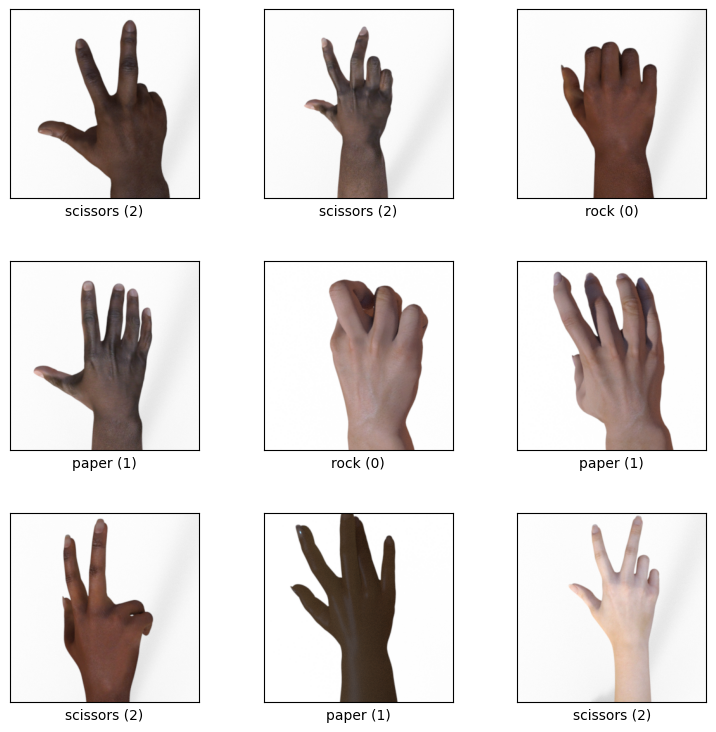

In [83]:
fig = tfds.show_examples(ds_train, ds_info)

W0000 00:00:1776403906.870157   67396 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


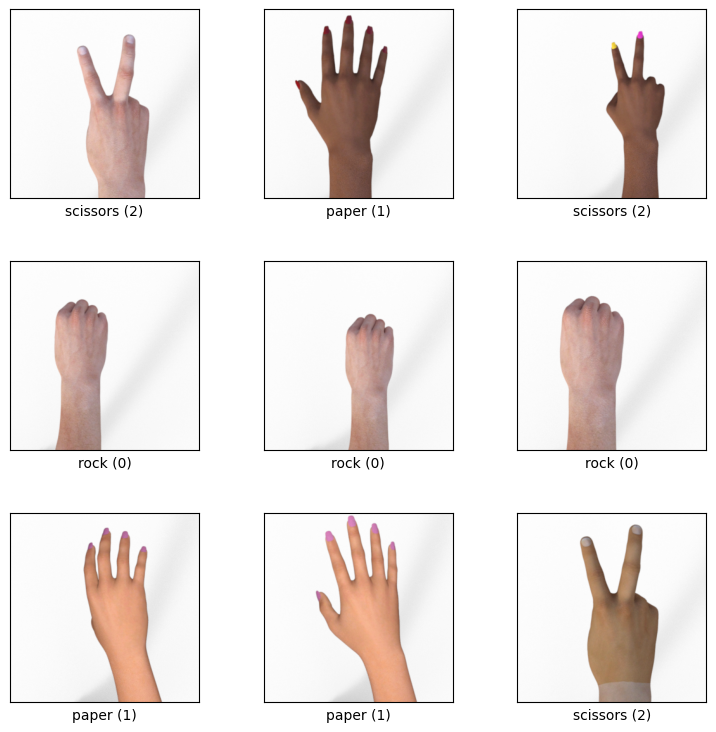

In [84]:
fig = tfds.show_examples(ds_test, ds_info)

### 3. How many classes are there?

In [85]:
num_classes = ds_info.features['label'].num_classes
class_names = ds_info.features['label'].names
print(f"Number of Classes: {num_classes}")
print(f"Class Names: {class_names}")

Number of Classes: 3
Class Names: ['rock', 'paper', 'scissors']


### 4. How many data points you have in each class? (Do this for both training and test data)

In [86]:
train_counts = {name: 0 for name in class_names}
test_counts = {name: 0 for name in class_names}
for image, label in ds_train:
    class_name = class_names[label.numpy()]
    train_counts[class_name] += 1
for image, label in ds_test:
    class_name = class_names[label.numpy()]
    test_counts[class_name] += 1
print("Training dataset class counts:")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")
print("\nTest dataset class counts:")
for class_name, count in test_counts.items():
    print(f"{class_name}: {count}")


Training dataset class counts:
rock: 840
paper: 840
scissors: 840

Test dataset class counts:
rock: 124
paper: 124
scissors: 124


### 5. Show some of the data point on screen.

Training Set Data Points

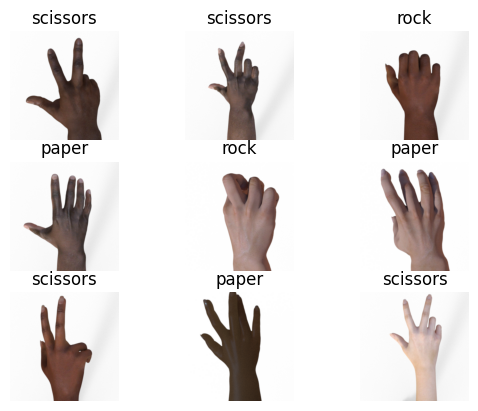

In [87]:
for i, (image, label) in enumerate(ds_train.take(9)):
    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(class_names[label.numpy()])
    plt.axis("off")


Test Set Data Points

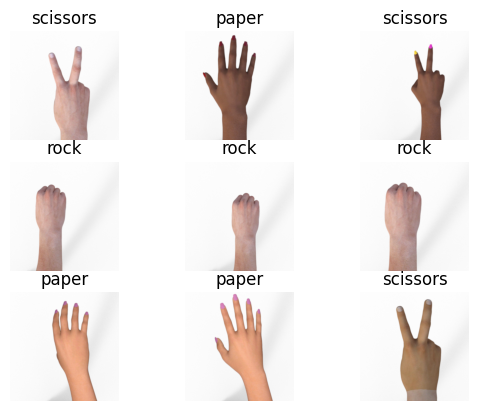

In [88]:
for i, (image, label) in enumerate(ds_test.take(9)):
    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(class_names[label.numpy()])
    plt.axis("off")

### 6. Do the required manipulations on data to make it ready for training and testing

In [89]:
imgsize = 64
def preprocess(image, label):
    image = tf.image.resize(image, [imgsize, imgsize])
    image = tf.cast(image, tf.float32) / 255.0 
    image = tf.reshape(image, [-1])               
    return image, label
batchsize = 32
train_ds = ds_train.map(preprocess).batch(batchsize).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).batch(batchsize).prefetch(tf.data.AUTOTUNE)

### 7. Construct your NN model. Use only Dense Layers. In first trial only have two dense layers.

In [90]:
model = models.Sequential([
    layers.Input(shape=(imgsize*imgsize*3,)),
    layers.Dense(2, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

### 8. For compile module use following settings:
### Optimizer : Adam
### Loss function : SparseCategoricalCrossentropy
### Metrics : Accuracy

In [91]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

### 9. After setting up parameters train your NN

In [92]:
history = model.fit(train_ds, epochs=15, validation_data=test_ds)

Epoch 1/10


I0000 00:00:1776403908.366038   67607 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_51424__.12


58/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3375 - loss: 1.3696

I0000 00:00:1776403909.246420   67608 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_51424__.12


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3274 - loss: 1.1417 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3254 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3238 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3238 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3234 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3234 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3143 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3123 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Ep

### 10. After training test your trained NN

In [93]:
test_loss, test_accuracy = model.evaluate(test_ds)


 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3750 - loss: 1.0983

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3333 - loss: 1.0986


### 11. Plot the confusion matrix

become one with the confusion

<function matplotlib.pyplot.show(close=None, block=None)>

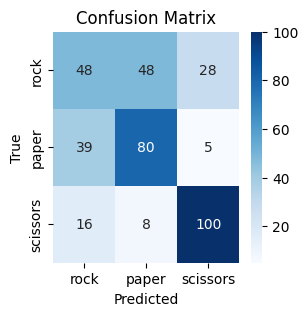

In [77]:
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show

